In [2]:
# perform simple machine learning technique using the data
# usd the data set from kaggle (Exam Score Prediction Dataset) for learning

In [3]:
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import OneHotEncoder

In [4]:
def median(data):
    data=deepcopy(data)
    N=len(data)
    if N//2:
        median=(data[N//2+1]+data[N//2])/2
    else:
        median=(data[(N+1)//2])
    return median

def M(data,k): #kth central moment
    # central moments has lots of use,
    # for example: (--> means related to)
    # k=0-->total
    # k=1-->mean, k=2-->variance
    # k=3-->skewness, k=4-->kurtosis
    data=deepcopy(data)
    Mk=0
    for i in data:
        Mk+=(i)**k
    return Mk

In [5]:
# no need for any path since the csv files is already right a branch file of chius
df = pd.read_csv(r"C:\Users\chius\Example to regressions.csv")
df_init=df.head(200)
#df_init=df
N=df_init.shape[0]
df_init

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,17,other,b.com,7.47,47.3,yes,7.1,poor,group study,low,moderate,66.6
196,197,19,other,diploma,5.71,77.1,yes,8.2,average,online videos,high,easy,83.5
197,198,17,male,b.tech,6.26,56.9,no,4.4,average,self-study,high,easy,70.9
198,199,19,female,b.tech,3.67,71.2,yes,8.3,good,mixed,low,easy,67.9


In [6]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        200 non-null    int64  
 1   age               200 non-null    int64  
 2   gender            200 non-null    object 
 3   course            200 non-null    object 
 4   study_hours       200 non-null    float64
 5   class_attendance  200 non-null    float64
 6   internet_access   200 non-null    object 
 7   sleep_hours       200 non-null    float64
 8   sleep_quality     200 non-null    object 
 9   study_method      200 non-null    object 
 10  facility_rating   200 non-null    object 
 11  exam_difficulty   200 non-null    object 
 12  exam_score        200 non-null    float64
dtypes: float64(4), int64(2), object(7)
memory usage: 20.4+ KB


In [7]:
df_init.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,20.575000,4.021000,68.918500,6.902500,61.381985
std,57.879185,2.213339,2.415061,17.277452,1.762577,19.138654
min,1.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,50.750000,19.000000,1.657500,53.750000,5.400000,49.000000
50%,100.500000,21.000000,3.975000,67.900000,6.900000,63.350000
75%,150.250000,23.000000,5.990000,83.750000,8.300000,74.925000
max,200.000000,24.000000,7.910000,99.400000,9.900000,100.000000


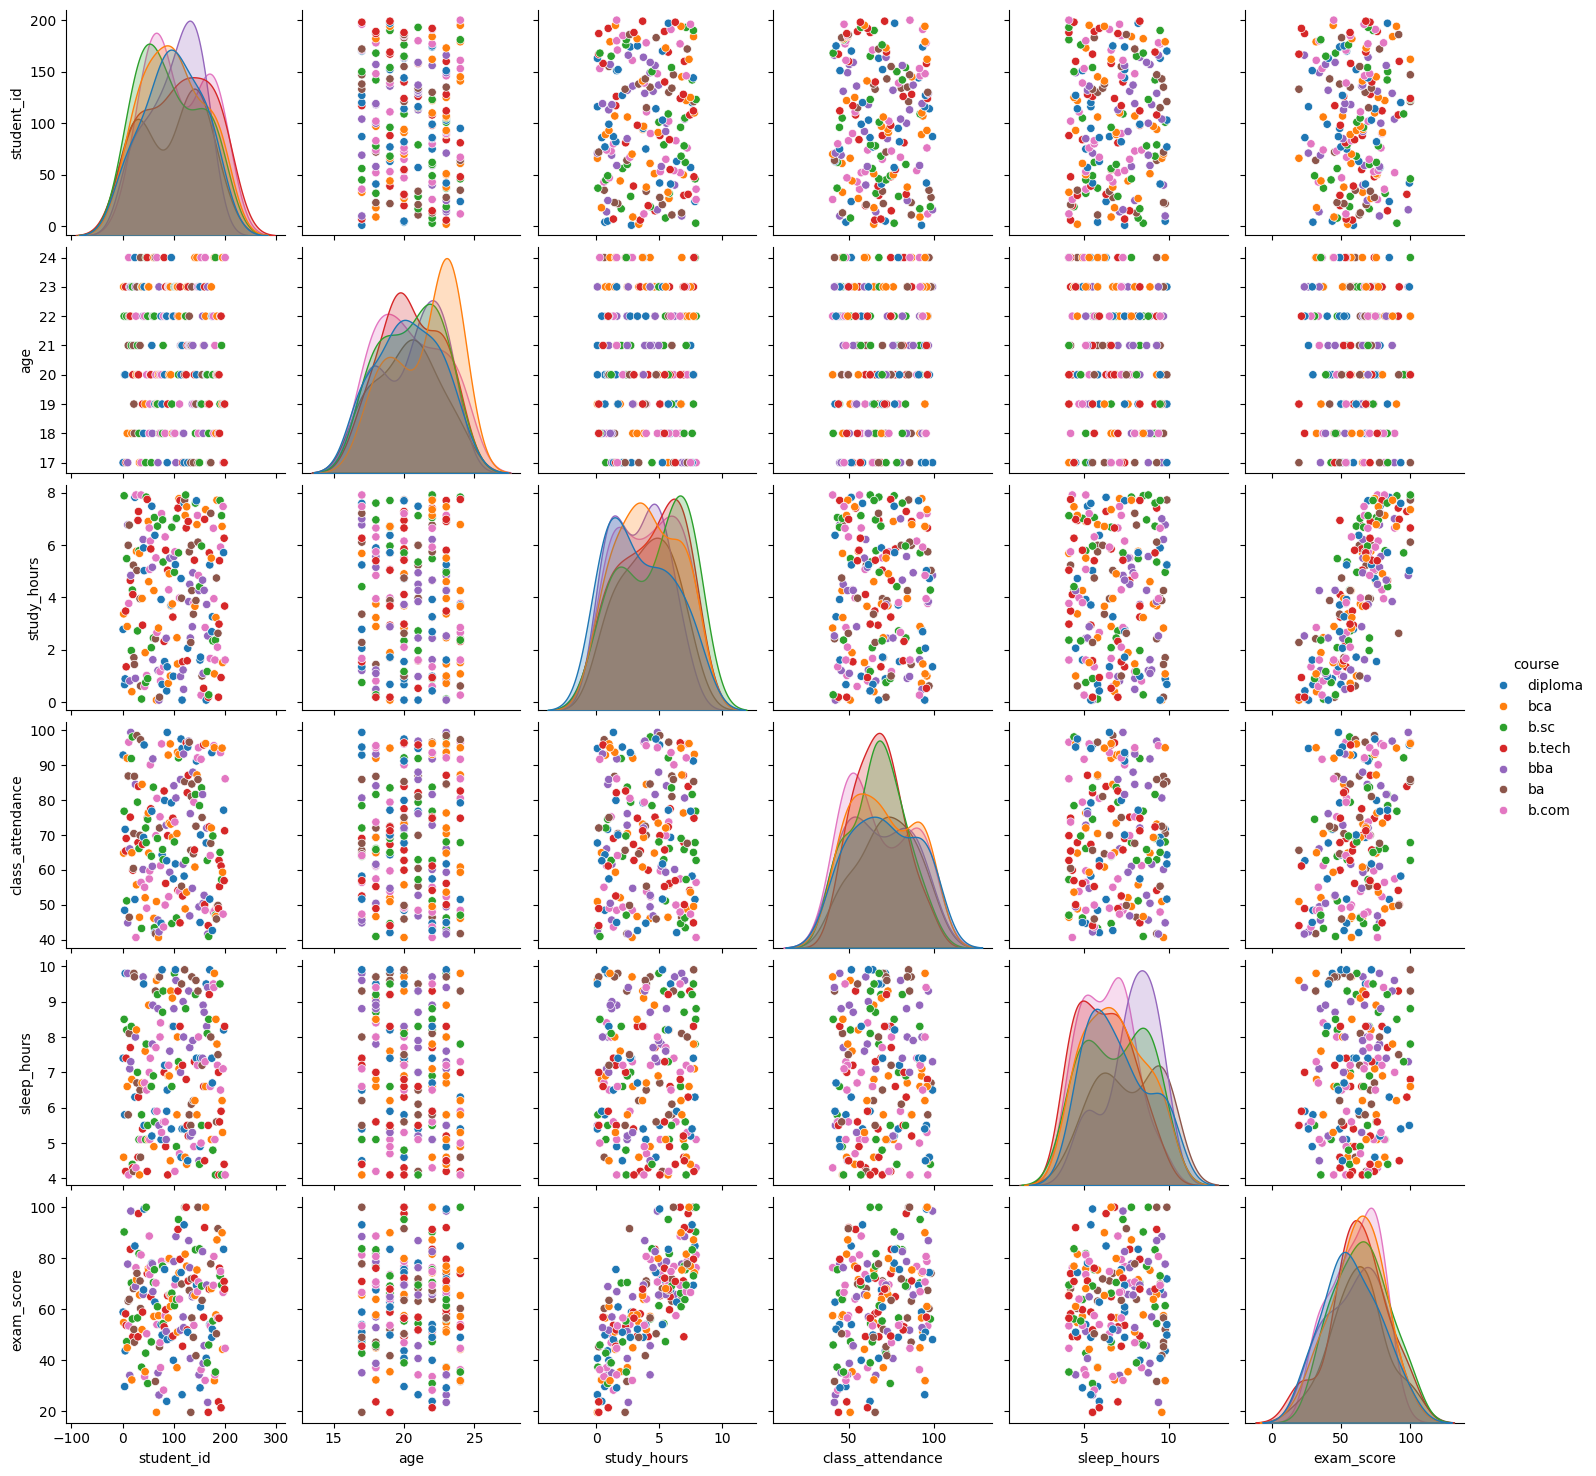

In [8]:
sns.pairplot(df_init, hue='course',height=2.5)

In [9]:
df_init['course'].value_counts()

course
bca        31
b.com      31
b.sc       30
b.tech     30
diploma    28
bba        27
ba         23
Name: count, dtype: int64

In [10]:
parameter={'gender':{'male':1.0,'female':2.0,'other':3.0},
           'internet_access':{'yes':1.0,'no':0.0},
           'sleep_quality':{'poor':1.0,'average':2.0,'good':3.0},
           'facility_rating':{'low':1.0,'medium':2.0,'high':3.0},
           'exam_difficulty':{'easy':3.0,'moderate':2.0,'hard':1.0}}

In [11]:
df_init=df_init.replace(parameter).infer_objects(copy=False)
df_init

C:\Users\chius\AppData\Local\Temp\ipykernel_24344\755218607.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_init=df_init.replace(parameter).infer_objects(copy=False)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1.0,diploma,2.78,92.9,1.0,7.4,1.0,coaching,1.0,1.0,58.9
1,2,23,3.0,bca,3.37,64.8,1.0,4.6,2.0,online videos,2.0,2.0,54.8
2,3,22,1.0,b.sc,7.88,76.8,1.0,8.5,1.0,coaching,3.0,2.0,90.3
3,4,20,3.0,diploma,0.67,48.4,1.0,5.8,2.0,online videos,1.0,2.0,29.7
4,5,20,2.0,diploma,0.89,71.6,1.0,9.8,1.0,coaching,1.0,2.0,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,17,3.0,b.com,7.47,47.3,1.0,7.1,1.0,group study,1.0,2.0,66.6
196,197,19,3.0,diploma,5.71,77.1,1.0,8.2,2.0,online videos,3.0,3.0,83.5
197,198,17,1.0,b.tech,6.26,56.9,0.0,4.4,2.0,self-study,3.0,3.0,70.9
198,199,19,2.0,b.tech,3.67,71.2,1.0,8.3,3.0,mixed,1.0,3.0,67.9


In [12]:
df_bca=df_init[df['course']=='bca']
df_bca
N=df_bca.shape[0]


C:\Users\chius\AppData\Local\Temp\ipykernel_24344\3432566059.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_bca=df_init[df['course']=='bca']


In [13]:
df_reg=df_bca.drop(columns=['course','study_method'],errors='ignore')
df_reg.corr()['exam_score']

student_id          0.327293
age                 0.125436
gender             -0.091499
study_hours         0.862502
class_attendance    0.116277
internet_access    -0.097823
sleep_hours        -0.261947
sleep_quality       0.086496
facility_rating     0.166796
exam_difficulty     0.146732
exam_score          1.000000
Name: exam_score, dtype: float64

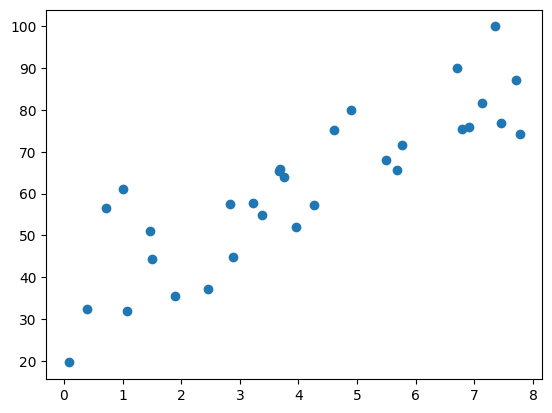

In [14]:
fig=plt.figure()
ax=fig.add_subplot(111)
ax.scatter(df_reg['study_hours'],df_reg['exam_score'])
plt.show()

In [15]:
df_np=df_reg.to_numpy()

In [16]:
filepath=r"C:\Users\chius\Example to Classifications.csv"
df=pd.read_csv(filepath)
df=df[df['Country']=='UK'].drop(columns=['Country'],errors='ignore')
print(df)

             Sales Person              Product        Date         Amount  \
0          Jehu Rudeforth      Mint Chip Choco  04/01/2022   US$5,320.00    
4          Jehu Rudeforth  Peanut Butter Cubes  24/02/2022  US$13,685.00    
6              Oby Sorrel      99% Dark & Pure  25/01/2022  US$13,685.00    
10    Rafaelita Blaksland   Smooth Sliky Salty  13/01/2022   US$4,704.00    
19         Curtice Advani        85% Dark Bars  08/06/2022   US$1,085.00    
...                   ...                  ...         ...            ...   
3235       Marney O'Breen        Drinking Coco  29/03/2024   US$1,135.16    
3242       Camilla Castle  Peanut Butter Cubes  19/07/2024   US$5,267.69    
3243      Madelene Upcott  Peanut Butter Cubes  12/08/2024   US$8,698.47    
3267         Jan Morforth  Baker's Choco Chips  11/03/2024     US$783.35    
3268       Jehu Rudeforth     Fruit & Nut Bars  13/05/2024   US$9,434.44    

      Boxes Shipped  
0               180  
4               184  
6        

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 0 to 3268
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   534 non-null    object
 1   Product        534 non-null    object
 2   Date           534 non-null    object
 3   Amount         534 non-null    object
 4   Boxes Shipped  534 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 25.0+ KB


In [18]:
df.describe()

,Boxes Shipped
count,534.000000
mean,173.264045
std,111.256155
min,2.000000
25%,85.250000
50%,155.500000
75%,232.000000
max,599.000000


In [19]:
x=df['Product'].value_counts()
choco_list=x.index.tolist()
choco_list=np.array(choco_list)
print(choco_list.shape)

(22,)


In [20]:
#encoding the factors so that they can be learnt by the computer

In [21]:
df_np=df.to_numpy()

In [22]:
enc = OneHotEncoder(sparse_output=False)
encoded_matrix = enc.fit_transform(df_np[:, 1].reshape(-1, 1))

column_names = enc.get_feature_names_out(['Product'])

df_encoded = pd.DataFrame(encoded_matrix, columns=column_names)

other_cols_indices = [0, 2, 3, 4]
df_others = pd.DataFrame(df_np[:, other_cols_indices], 
                         columns=['Sales_Person', 'Date', 'Amount', 'Boxes_Shipped'])

# 5. Concatenate them side-by-side
df_final = pd.concat([df_others, df_encoded], axis=1)

# Display the result
print(df_final)

            Sales_Person        Date         Amount Boxes_Shipped  \
0         Jehu Rudeforth  04/01/2022   US$5,320.00            180   
1         Jehu Rudeforth  24/02/2022  US$13,685.00            184   
2             Oby Sorrel  25/01/2022  US$13,685.00            176   
3    Rafaelita Blaksland  13/01/2022   US$4,704.00             62   
4         Curtice Advani  08/06/2022   US$1,085.00            172   
..                   ...         ...            ...           ...   
529       Marney O'Breen  29/03/2024   US$1,135.16             27   
530       Camilla Castle  19/07/2024   US$5,267.69            120   
531      Madelene Upcott  12/08/2024   US$8,698.47             89   
532         Jan Morforth  11/03/2024     US$783.35            273   
533       Jehu Rudeforth  13/05/2024   US$9,434.44            221   

     Product_50% Dark Bites  Product_70% Dark Bites  Product_85% Dark Bars  \
0                       0.0                     0.0                    0.0   
1              